# Actividad 4 - Parte 2: Análisis de sobrevivencia en el Titanic

Esta sección de la actividad se enfoca en la creación y evaluación de un modelo de regresión logística binaria. El objetivo principal será determinar las variables más significativas para predecir la sobrevivencia de los pasajeros del Titanic.

## 1. Preparación de los datos

Importamos las bibliotecas necesarias y cargamos la base de datos en una variable.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("titanic.csv")
df.head()


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [36]:
print(df.shape)
print(df.dtypes)


(1309, 14)
pclass       int64
survived     int64
name           str
sex            str
age            str
sibsp        int64
parch        int64
ticket         str
fare           str
cabin          str
embarked       str
boat           str
body           str
home.dest      str
dtype: object


## 2. Limpieza de datos

Examina las columnas disponibles en tu conjunto de datos y decide cuáles no son necesarias para tu análisis, elimina las que no consideres necesarias.  Además, identifica los datos nulos que tengas y elimínalos.

In [37]:
# Columnas disponibles
print("Columnas:", df.columns.tolist())


Columnas: ['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']


In [38]:
# Eliminamos columnas que no son relevantes para predecir sobrevivencia
df = df.drop(columns=["name", "ticket", "cabin", "boat", "body", "home.dest"])
print("Columnas utiles:", df.columns.tolist())



Columnas utiles: ['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [39]:
# En este dataset los valores faltantes están puestos como "?"

df = df.replace("?", np.nan)

# Verificamos cuántos nulos hay por columna
print("Valores nulos por columna:")
print(df.isnull().sum())



Valores nulos por columna:
pclass        0
survived      0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64


In [40]:
# Eliminamos las filas con valores nulos
df = df.dropna()



## 3. Conversión de variables a su formato correcto

Dependiendo de las variables en tu conjunto de datos, es posible que necesites convertir algunas de ellas a un tipo de dato más apropiado, como convertir variables categóricas a tipo 'category' o ajustar las fechas a un formato de fecha y hora.

In [41]:
# Convertimos columnas numéricas
df["age"] = pd.to_numeric(df["age"])
df["fare"] = pd.to_numeric(df["fare"])

# Convertimos columnas categóricas
df["sex"] = df["sex"].astype("category")
df["embarked"] = df["embarked"].astype("category")

print(df.dtypes)
df.head()



pclass         int64
survived       int64
sex         category
age          float64
sibsp          int64
parch          int64
fare         float64
embarked    category
dtype: object


,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,female,29.0000,0,0,211.3375,S
1,1,1,male,0.9167,1,2,151.5500,S
2,1,0,female,2.0000,1,2,151.5500,S
3,1,0,male,30.0000,1,2,151.5500,S
4,1,0,female,25.0000,1,2,151.5500,S


In [42]:
le = LabelEncoder()
df["sex_cod"] = le.fit_transform(df["sex"])
df["embarked_cod"] = le.fit_transform(df["embarked"])

print("Valor de 'sex':")
print(df[["sex", "sex_cod"]].drop_duplicates())



Valor de 'sex':
      sex  sex_cod
0  female        0
1    male        1


## 4. Visualización de datos

Analiza los datos de forma gráfica para verificar que existe una relación entre la variable dependiente y la independiente.

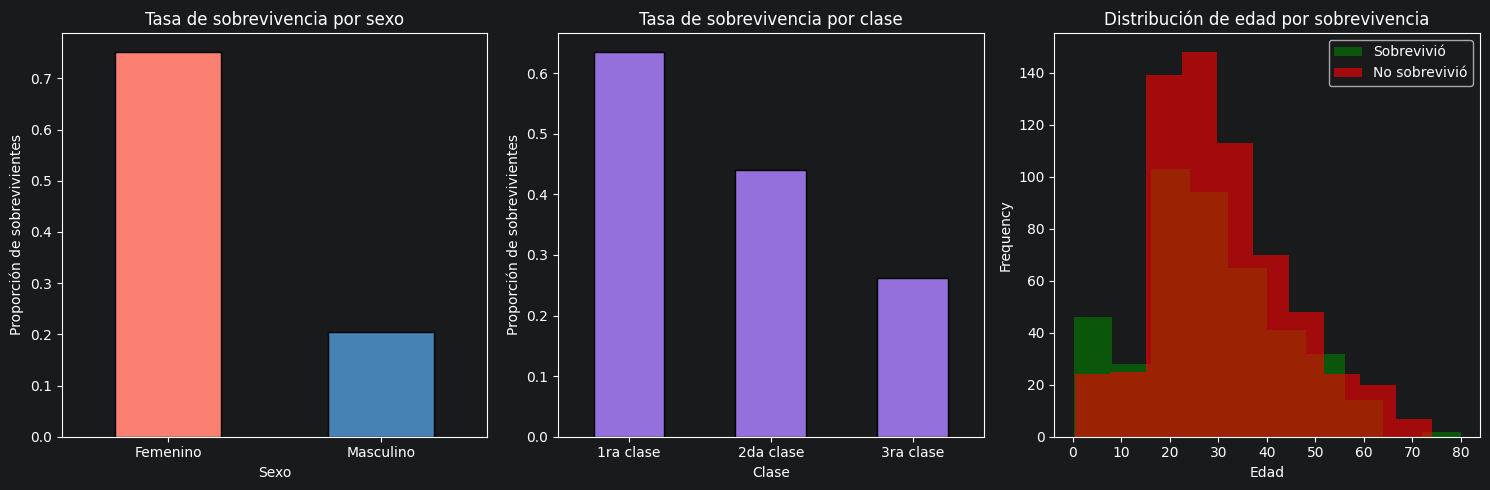

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Tasa de sobrevivencia por sexo
df.groupby("sex")["survived"].mean().plot(kind="bar", ax=axes[0], color=["salmon", "steelblue"], edgecolor="black")
axes[0].set_title("Tasa de sobrevivencia por sexo")
axes[0].set_xlabel("Sexo")
axes[0].set_ylabel("Proporción de sobrevivientes")
axes[0].set_xticklabels(["Femenino", "Masculino"], rotation=0)

# Tasa de sobrevivencia por clase
df.groupby("pclass")["survived"].mean().plot(kind="bar", ax=axes[1], color="mediumpurple", edgecolor="black")
axes[1].set_title("Tasa de sobrevivencia por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Proporción de sobrevivientes")
axes[1].set_xticklabels(["1ra clase", "2da clase", "3ra clase"], rotation=0)

# Distribución de edad por sobrevivencia
df[df["survived"] == 1]["age"].plot(kind="hist", ax=axes[2], alpha=0.6, color="green", label="Sobrevivió")
df[df["survived"] == 0]["age"].plot(kind="hist", ax=axes[2], alpha=0.6, color="red", label="No sobrevivió")
axes[2].set_title("Distribución de edad por sobrevivencia")
axes[2].set_xlabel("Edad")
axes[2].legend()

plt.tight_layout()
plt.show()



__Interpretación:__
- Las mujeres tuvieron una tasa de sobrevivencia notablemente más alta que los hombres.
- Los pasajeros de primera clase sobrevivieron en mayor proporción que los de segunda y tercera clase.
- La distribución de edad es similar entre sobrevivientes y no sobrevivientes, aunque los niños pequeños parecen tener mayor proporción de sobrevivencia.

## 5. Prueba t-test

Aplicamos una prueba t para verificar si existe una diferencia estadísticamente significativa en la __edad__ entre los pasajeros que sobrevivieron y los que no.

In [44]:
# Separamos las edades por grupo
sobrevivieron = df[df["survived"] == 1]["age"]
no_sobrevivieron = df[df["survived"] == 0]["age"]

# Aplicamos la prueba t
t_stat, p_value = stats.ttest_ind(sobrevivieron, no_sobrevivieron)

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

print(f"\nEdad promedio de sobrevivientes: {sobrevivieron.mean():.2f} años")
print(f"Edad promedio de no sobrevivientes: {no_sobrevivieron.mean():.2f} años")



Estadístico t: -1.8555
Valor p: 0.0638

Edad promedio de sobrevivientes: 28.82 años
Edad promedio de no sobrevivientes: 30.50 años


__Interpretacion:__

No hay una diferencia estadísticamente significativa en la edad entre los grupos (p >= 0.05).



## 6. División de datos

Divide los datos en variables de prueba y de entrenamiento. Esto es crucial para entrenar el modelo y luego evaluar su capacidad para generalizar a nuevos datos

In [45]:
# Variables independientes
X = df[["pclass", "sex_cod", "age", "sibsp", "parch", "fare"]]

# Variable dependiente
y = df["survived"]

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 7. Creación del modelo

Creamos el modelo de regresión logística binaria y lo entrenamos con los datos de entrenamiento.

In [50]:
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)


## 8. Estimación de los coeficientes y los odds ratio

Una vez que entrenaste el modelo, el siguiente paso es interpretar los resultados. Esto se hace mediante la estimación de los coeficientes, los cuales te indicarán la fuerza y dirección de la relación entre cada variable independiente y la variable dependiente.

In [52]:
# Coeficientes del modelo
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_[0],
    "Odds Ratio": np.exp(modelo.coef_[0])
})

coeficientes = coeficientes.sort_values("Odds Ratio", ascending=False)
print(coeficientes.to_string(index=False))



Variable  Coeficiente  Odds Ratio
   parch     0.106183    1.112025
    fare     0.001395    1.001396
     age    -0.042647    0.958249
   sibsp    -0.458269    0.632377
  pclass    -1.169060    0.310659
 sex_cod    -2.566516    0.076803


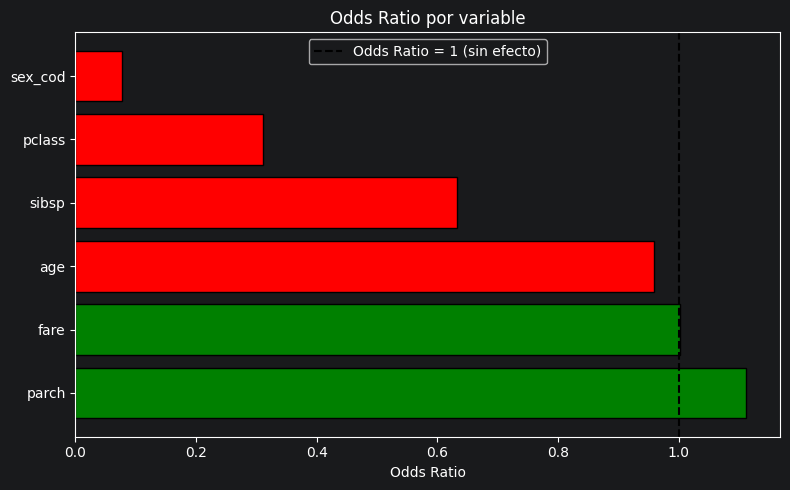

In [53]:
# Visualizamos los odds ratio
plt.figure(figsize=(8, 5))
colors = ["green" if x > 1 else "red" for x in coeficientes["Odds Ratio"]]
plt.barh(coeficientes["Variable"], coeficientes["Odds Ratio"], color=colors, edgecolor="black")
plt.axvline(x=1, color="black", linestyle="--", label="Odds Ratio = 1 (sin efecto)")
plt.title("Odds Ratio por variable")
plt.xlabel("Odds Ratio")
plt.legend()
plt.tight_layout()
plt.show()



__Interpretación de los odds ratio:__
- __Odds Ratio > 1 (barras verdes):__ La variable aumenta la probabilidad de sobrevivir.
- __Odds Ratio < 1 (barras rojas):__ La variable disminuye la probabilidad de sobrevivir.
- Por ejemplo, si `sex_cod` tiene odds ratio menor a 1, significa que ser hombre (codificado como 1) reduce significativamente la probabilidad de sobrevivir comparado con ser mujer.

## 9. Conclusión

- Las variables con __mayor impacto__ en la probabilidad de sobrevivencia fueron:
  - __Sexo:__ Las mujeres tuvieron una probabilidad mucho mayor de sobrevivir (política de "mujeres y niños primero").
  - __Clase del pasajero:__ Los pasajeros de primera clase tuvieron mayor acceso a botes salvavidas, aumentando su probabilidad de sobrevivencia.
  - __Tarifa pagada (fare):__ Relacionada con la clase, también mostró efecto positivo.

__Posibles mejoras:__
- No se me ocurrieron